# Results walkthrough

A read-only tour of the evaluation artifacts this repository already ships. Every figure below is
computed from committed JSON and CSV under `reports/` - **no checkpoint is loaded and no inference is
run**, so the notebook executes in seconds on any machine that can `import matplotlib`.

For how to *reproduce* those artifacts, see `README.md` (local pipeline) and `COLAB_TRAINING.md`
(GPU runbook). For the interactive demo, see `notebooks/demo.ipynb`. This notebook answers a
different question: **what did the evaluation actually show?**

What follows, in order:

1. **Cross-domain transfer** - why the project needed SID adaptation at all
2. **Robustness** - how both checkpoints hold up under JPEG, blur, downscaling and noise
3. **Generator subgroups** - which kind of AI image is actually hard
4. **Robustness evaluation summary** - a compact table and figure of the deployed checkpoint's own clean-vs-transformed performance
5. **Test-time augmentation** - what the inference policy buys
6. **Error analysis** - what the residual mistakes look like

> **A note on sample sizes.** Sections 2-5 evaluate the same 2,000-image SID test split. Section 1
> additionally reports one CIFAKE in-domain row (20,000 images) for contrast, and section 6 reads a
> CIFAKE-domain error log produced by an earlier, superseded CLIP-plus-forensic architecture - not the
> LoRA Swin-Tiny checkpoint that ships. They are not interchangeable, and each figure states which it
> is using.

## Setup

Imports, paths and the plotting theme. The palette is fixed here so colour means the same thing in
every figure: **blue is the deployed SID LoRA checkpoint, orange is the pre-SID CIFAKE checkpoint.**

The table this cell prints is the availability check - `reports/metrics/*.json` is committed, but
`reports/notebook/` may not be on a fresh clone. Cells whose inputs are missing print a note and skip
rather than failing.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve the repository root whether the kernel starts in the repo or in notebooks/.
ROOT = Path.cwd()
if not (ROOT / "reports").is_dir() and (ROOT.parent / "reports").is_dir():
    ROOT = ROOT.parent
METRICS = ROOT / "reports" / "metrics"
NB_REPORTS = ROOT / "reports" / "notebook"

# Palette: categorical slots 1-3 of the validated default palette, light surface.
# Colour follows the entity across every figure in this notebook:
#   BLUE = the deployed SID LoRA, ORANGE = the pre-SID CIFAKE checkpoint.
INK, INK_2, INK_MUTE = "#0b0b0b", "#52514e", "#8a8880"
SURFACE, GRID, NEUTRAL = "#fcfcfb", "#e6e5e1", "#b9b7b0"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "figure.dpi": 120,
    "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.8,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",          # solid hairline grid, never dashed
    "xtick.color": INK_MUTE,
    "ytick.color": INK_MUTE,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "legend.labelcolor": INK_2,
    "font.size": 9.5,
    "font.family": "sans-serif",
})


def load_json(path):
    # Return parsed JSON, or None when the artifact is absent.
    path = Path(path)
    if not path.is_file():
        return None
    with path.open() as fh:
        return json.load(fh)


def require(*objs):
    # Guard for cells that need artifacts which may not be present.
    missing = [o for o in objs if o is None]
    if missing:
        raise RuntimeError("required report artifact missing - see the availability table above")


ARTIFACTS = {
    "cifake_in_domain": METRICS / "pre_sid_cifake_robustness.json",
    "sid_before_lora": METRICS / "pre_sid_sid_holdout_robustness.json",
    "sid_after_lora": METRICS / "sid_local_lora_test_robustness.json",
    "sid_after_lora_tta": METRICS / "sid_local_lora_tta_test_robustness.json",
    "inference_policy": METRICS / "inference_policy_validation.json",
    "error_analysis": NB_REPORTS / "error_analysis.json",
    "demo_predictions": NB_REPORTS / "demo_predictions.json",
}

availability = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(p.relative_to(ROOT)),
            "found": "yes" if p.is_file() else "MISSING",
        }
        for name, p in ARTIFACTS.items()
    ]
)
availability

,artifact,path,found
0,cifake_in_domain,reports/metrics/pre_sid_cifake_robustness.json,yes
1,sid_before_lora,reports/metrics/pre_sid_sid_holdout_robustness...,yes
2,sid_after_lora,reports/metrics/sid_local_lora_test_robustness...,yes
3,sid_after_lora_tta,reports/metrics/sid_local_lora_tta_test_robust...,yes
4,inference_policy,reports/metrics/inference_policy_validation.json,yes
5,error_analysis,reports/notebook/error_analysis.json,yes
6,demo_predictions,reports/notebook/demo_predictions.json,yes


## 1. Cross-domain transfer is the whole problem

The single most important number in this project is not the in-domain score - it is what happens when
the CIFAKE-trained checkpoint meets a different data distribution.

All three rows below are the same evaluation code at each configuration's own tuned threshold.

In [2]:
cifake_in = load_json(ARTIFACTS["cifake_in_domain"])
sid_before = load_json(ARTIFACTS["sid_before_lora"])
sid_after = load_json(ARTIFACTS["sid_after_lora"])
sid_tta = load_json(ARTIFACTS["sid_after_lora_tta"])
require(cifake_in, sid_before, sid_after)

CONFIGS = [
    ("CIFAKE LoRA on CIFAKE test", cifake_in, "in-domain"),
    ("CIFAKE LoRA on SID test", sid_before, "cross-domain, before adaptation"),
    ("SID LoRA on SID test", sid_after, "cross-domain, after adaptation"),
]

headline = pd.DataFrame(
    [
        {
            "configuration": name,
            "regime": regime,
            "n": doc["transforms"]["clean"]["samples"],
            "auroc": doc["transforms"]["clean"]["auroc"],
            "balanced_acc": doc["transforms"]["clean"]["balanced_accuracy"],
            "recall": doc["transforms"]["clean"]["recall"],
            "fpr": doc["transforms"]["clean"]["false_positive_rate"],
        }
        for name, doc, regime in CONFIGS
    ]
)
headline.round(4)

,configuration,regime,n,auroc,balanced_acc,recall,fpr
0,CIFAKE LoRA on CIFAKE test,in-domain,20000,0.9970,0.9742,0.9801,0.0316
1,CIFAKE LoRA on SID test,"cross-domain, before adaptation",2000,0.7535,0.5875,0.9390,0.7640
2,SID LoRA on SID test,"cross-domain, after adaptation",2000,0.9427,0.8645,0.8910,0.1620


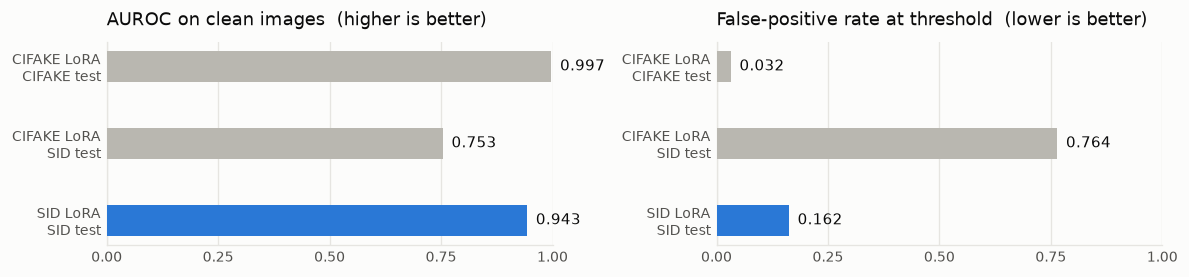

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 2.4))

# Emphasis rather than three hues: the deployed configuration is blue, its context neutral.
colours = [NEUTRAL, NEUTRAL, BLUE]
labels = ["CIFAKE LoRA\nCIFAKE test", "CIFAKE LoRA\nSID test", "SID LoRA\nSID test"]
y = np.arange(len(labels))[::-1]

panels = [
    ("AUROC on clean images  (higher is better)", "auroc"),
    ("False-positive rate at threshold  (lower is better)", "fpr"),
]

for ax, (title, col) in zip(axes, panels):
    vals = headline[col].to_numpy()
    ax.barh(y, vals, height=0.40, color=colours, zorder=3)
    for yi, v in zip(y, vals):
        ax.text(v + 0.02, yi, f"{v:.3f}", va="center", ha="left",
                fontsize=9, color=INK, zorder=4)
    ax.set_yticks(y, labels)
    ax.set_xlim(0, 1.0)
    ax.set_xticks(np.arange(0, 1.01, 0.25))
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

Read the false-positive column first. A detector that calls 76% of real photographs
AI-generated is not a weak detector, it is an unusable one, and the in-domain AUROC of 0.997 gives no
warning of it. This is the gap the SID LoRA stage exists to close.

## 2. Robustness under post-processing

Any real image has been through a pipeline - re-encoded, resized, maybe filtered. The evaluation
applies 14 perturbations to the same test split and re-scores.

Both models are evaluated on the **same 2,000-image SID test split**, so the two lines in each panel
are directly comparable.

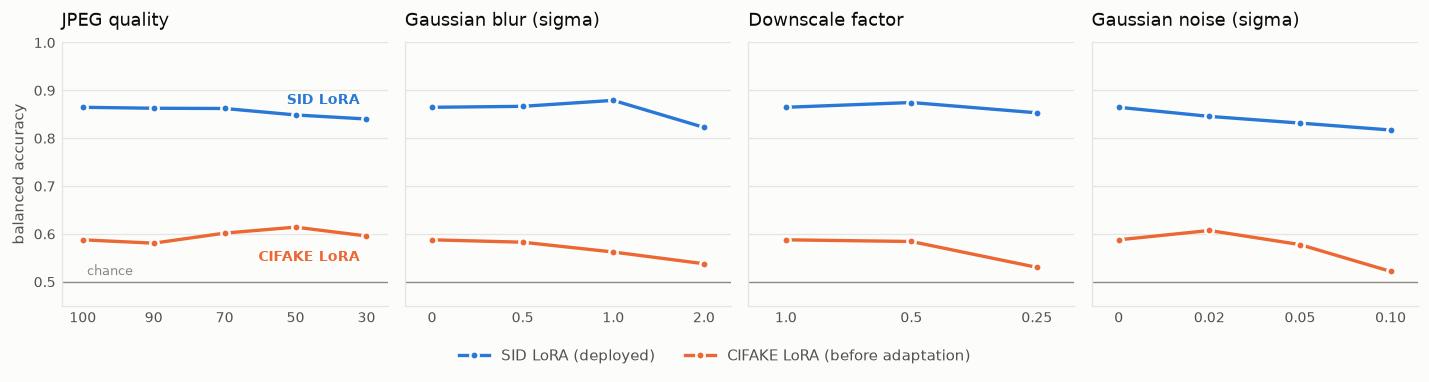

In [4]:
# Perturbation families, ordered mild -> severe. "clean" anchors each family at zero severity.
FAMILIES = {
    "JPEG quality": [("clean", "100"), ("jpeg_90", "90"), ("jpeg_70", "70"),
                     ("jpeg_50", "50"), ("jpeg_30", "30")],
    "Gaussian blur (sigma)": [("clean", "0"), ("blur_0.5", "0.5"), ("blur_1.0", "1.0"),
                              ("blur_2.0", "2.0")],
    "Downscale factor": [("clean", "1.0"), ("resize_0.5", "0.5"), ("resize_0.25", "0.25")],
    "Gaussian noise (sigma)": [("clean", "0"), ("noise_0.02", "0.02"),
                               ("noise_0.05", "0.05"), ("noise_0.10", "0.10")],
}

MODELS = [
    ("SID LoRA (deployed)", sid_after, BLUE),
    ("CIFAKE LoRA (before adaptation)", sid_before, ORANGE),
]

METRIC = "balanced_accuracy"

fig, axes = plt.subplots(1, 4, figsize=(12.0, 2.9), sharey=True)

for ax, (family, steps) in zip(axes, FAMILIES.items()):
    x = np.arange(len(steps))
    for name, doc, colour in MODELS:
        vals = [doc["transforms"][key][METRIC] for key, _ in steps]
        ax.plot(x, vals, color=colour, linewidth=2, marker="o", markersize=5,
                markeredgecolor=SURFACE, markeredgewidth=1.5, label=name, zorder=3)
    ax.axhline(0.5, color=INK_MUTE, linewidth=0.8, zorder=2)
    ax.set_xticks(x, [lab for _, lab in steps])
    ax.set_title(family)
    ax.set_xlim(-0.3, len(steps) - 0.7)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)

axes[0].set_ylim(0.45, 1.0)
axes[0].set_ylabel("balanced accuracy")
axes[0].text(0.06, 0.507, "chance", fontsize=8, color=INK_MUTE, va="bottom")

# Direct labels on the first facet; the SID LoRA line sits above the other throughout.
first = FAMILIES["JPEG quality"]
xi = len(first) - 1
axes[0].annotate("SID LoRA", (xi, sid_after["transforms"][first[xi][0]][METRIC]),
                 textcoords="offset points", xytext=(-4, 9), ha="right",
                 fontsize=8.5, color=BLUE, weight="bold")
axes[0].annotate("CIFAKE LoRA", (xi, sid_before["transforms"][first[xi][0]][METRIC]),
                 textcoords="offset points", xytext=(-4, -15), ha="right",
                 fontsize=8.5, color=ORANGE, weight="bold")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.tight_layout()
fig.legend(handles, labels_, loc="lower center", bbox_to_anchor=(0.5, -0.10), ncols=2)
plt.show()

The shapes differ in kind, not just degree. The pre-adaptation model degrades
catastrophically under blur and downscaling - it was reading CIFAKE's 32x32 upsampling signature, and
resampling destroys it. The adapted model's worst case across all 14 perturbations is a 4.8-point drop
in balanced accuracy.

The full numbers, including the `color_0.2` and `crop_0.8` variants that are not in the curves above:

In [5]:
rows = []
for key in sid_after["transforms"]:
    row = {"transform": key}
    for name, doc, _ in MODELS:
        row[f"{name} auroc"] = doc["transforms"][key]["auroc"]
        row[f"{name} bal_acc"] = doc["transforms"][key]["balanced_accuracy"]
    rows.append(row)

robustness_table = pd.DataFrame(rows).set_index("transform")
robustness_table.round(4)

,SID LoRA (deployed) auroc,SID LoRA (deployed) bal_acc,CIFAKE LoRA (before adaptation) auroc,CIFAKE LoRA (before adaptation) bal_acc
transform,,,,
clean,0.9427,0.8645,0.7535,0.5875
jpeg_90,0.9394,0.8625,0.7510,0.5805
jpeg_70,0.9351,0.8620,0.7671,0.6015
jpeg_50,0.9308,0.8485,0.7656,0.6140
jpeg_30,0.9247,0.8400,0.7511,0.5955
blur_0.5,0.9456,0.8665,0.7502,0.5825
blur_1.0,0.9503,0.8790,0.7336,0.5620
blur_2.0,0.9059,0.8225,0.7101,0.5375
resize_0.5,0.9511,0.8745,0.7499,0.5840


## 3. Locally tampered images are the hard class

The SID test split is not homogeneous. It carries three subgroups, and averaging over them hides the
result that matters most for deployment.

In [6]:
def subgroup_frame(doc, model_name, variant="clean"):
    rows = []
    for entry in doc["transforms"][variant]["subgroups"].values():
        rows.append({
            "model": model_name,
            "generator": entry["generator"],
            "truth": "AI" if entry["binary_label"] == 1 else "real",
            "samples": entry["samples"],
            "accuracy": entry["accuracy"],
            "mean_probability": entry["mean_probability"],
        })
    return pd.DataFrame(rows)


subgroups = pd.concat([
    subgroup_frame(sid_after, "SID LoRA"),
    subgroup_frame(sid_before, "CIFAKE LoRA"),
], ignore_index=True)

order = ["openimages_v7", "full_synthetic", "tampered"]
subgroups.pivot(index="generator", columns="model", values="accuracy").loc[order].round(4)

model,CIFAKE LoRA,SID LoRA
generator,,
openimages_v7,0.236,0.838
full_synthetic,0.992,0.998
tampered,0.886,0.784


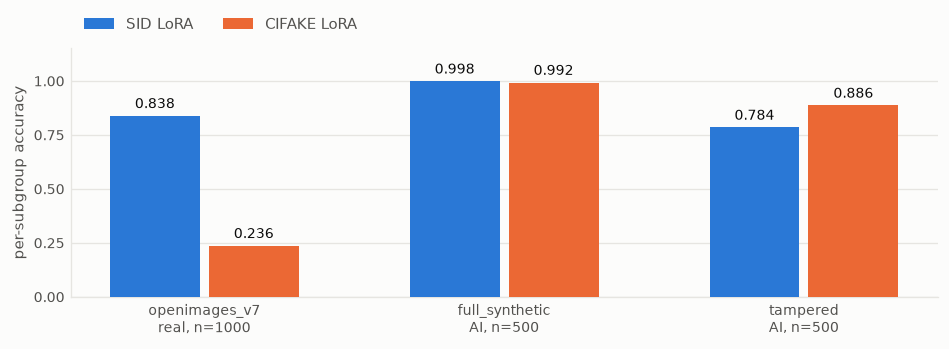

In [7]:
fig, ax = plt.subplots(figsize=(8.0, 3.0))

pivot = subgroups.pivot(index="generator", columns="model", values="accuracy").loc[order]
x = np.arange(len(order))
width = 0.30
series = [("SID LoRA", BLUE), ("CIFAKE LoRA", ORANGE)]

for i, (name, colour) in enumerate(series):
    # The gap between adjacent bars is surface, not a drawn border.
    offset = (i - 0.5) * (width + 0.03)
    vals = pivot[name].to_numpy()
    ax.bar(x + offset, vals, width=width, color=colour, label=name, zorder=3)
    for xi, v in zip(x + offset, vals):
        ax.text(xi, v + 0.02, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, color=INK, zorder=4)

counts = subgroups[subgroups.model == "SID LoRA"].set_index("generator").loc[order, "samples"]
truths = subgroups[subgroups.model == "SID LoRA"].set_index("generator").loc[order, "truth"]
ax.set_xticks(x, [f"{g}\n{t}, n={n}" for g, t, n in zip(order, truths, counts)])
ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.01, 0.25))
ax.set_ylabel("per-subgroup accuracy")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncols=2)

fig.tight_layout()
plt.show()

This is the most actionable finding in the evaluation. For the deployed model, fully
synthetic images are close to solved at 99.8%. **Locally tampered images** - real photographs with an
edited region - land 21 points lower, and they are also the more realistic threat model. An aggregate
accuracy figure averages that gap away.

The orange bars need reading with care. The pre-SID checkpoint scores *higher* than the deployed model
on both AI subgroups, but that is not skill: it calls almost everything AI, which is exactly why its
real-photograph accuracy is 0.236. Per-class accuracy is only interpretable alongside the false-positive
rate from section 1.

## 4. Robustness evaluation summary

Section 2 compares two checkpoints across four perturbation families. This section asks the sharper,
single-model question: for the **deployed SID LoRA checkpoint** alone, exactly how much does each of
the 14 conditions move AUROC, balanced accuracy, recall and false-positive rate away from clean? One
table, one figure, all at that checkpoint's own tuned threshold.

A fuller write-up of this same evaluation - including the fixed-threshold operating-point drift and
the test-time-augmentation comparison - ships as `reports/deliverables/04_robustness_evaluation_summary.pdf`.

In [8]:
FAMILY = {
    "clean": "Clean",
    "jpeg_90": "JPEG", "jpeg_70": "JPEG", "jpeg_50": "JPEG", "jpeg_30": "JPEG",
    "blur_0.5": "Blur", "blur_1.0": "Blur", "blur_2.0": "Blur",
    "resize_0.5": "Resize", "resize_0.25": "Resize",
    "noise_0.02": "Noise", "noise_0.05": "Noise", "noise_0.10": "Noise",
    "color_0.2": "Colour", "crop_0.8": "Crop",
}
LABEL = {
    "clean": "clean",
    "jpeg_90": "JPEG q90", "jpeg_70": "JPEG q70", "jpeg_50": "JPEG q50", "jpeg_30": "JPEG q30",
    "blur_0.5": "blur σ0.5", "blur_1.0": "blur σ1.0", "blur_2.0": "blur σ2.0",
    "resize_0.5": "resize ½", "resize_0.25": "resize ¼",
    "noise_0.02": "noise .02", "noise_0.05": "noise .05", "noise_0.10": "noise .10",
    "color_0.2": "colour jitter", "crop_0.8": "crop 0.8",
}
ORDER = list(sid_after["transforms"].keys())
CLEAN_T = sid_after["transforms"]["clean"]

summary_rows = []
for key in ORDER:
    v = sid_after["transforms"][key]
    summary_rows.append({
        "condition": LABEL[key],
        "family": FAMILY[key],
        "auroc": v["auroc"],
        "delta_vs_clean": np.nan if key == "clean" else v["auroc"] - CLEAN_T["auroc"],
        "balanced_accuracy": v["balanced_accuracy"],
        "recall": v["recall"],
        "fpr": v["false_positive_rate"],
    })

s = sid_after["summary"]
summary_rows.append({
    "condition": "mean of 14 transformed", "family": "-",
    "auroc": s["mean_transformed_auroc"],
    "delta_vs_clean": s["mean_transformed_auroc"] - CLEAN_T["auroc"],
    "balanced_accuracy": s["mean_transformed_balanced_accuracy"],
    "recall": np.nan, "fpr": np.nan,
})

robustness_summary = pd.DataFrame(summary_rows).set_index("condition")
robustness_summary.round(4)

,family,auroc,delta_vs_clean,balanced_accuracy,recall,fpr
condition,,,,,,
clean,Clean,0.9427,NaN,0.8645,0.891,0.162
JPEG q90,JPEG,0.9394,-0.0033,0.8625,0.870,0.145
JPEG q70,JPEG,0.9351,-0.0076,0.8620,0.850,0.126
JPEG q50,JPEG,0.9308,-0.0119,0.8485,0.762,0.065
JPEG q30,JPEG,0.9247,-0.0180,0.8400,0.720,0.040
blur σ0.5,Blur,0.9456,0.0029,0.8665,0.879,0.146
blur σ1.0,Blur,0.9503,0.0076,0.8790,0.835,0.077
blur σ2.0,Blur,0.9059,-0.0368,0.8225,0.694,0.049
resize ½,Resize,0.9511,0.0084,0.8745,0.903,0.154


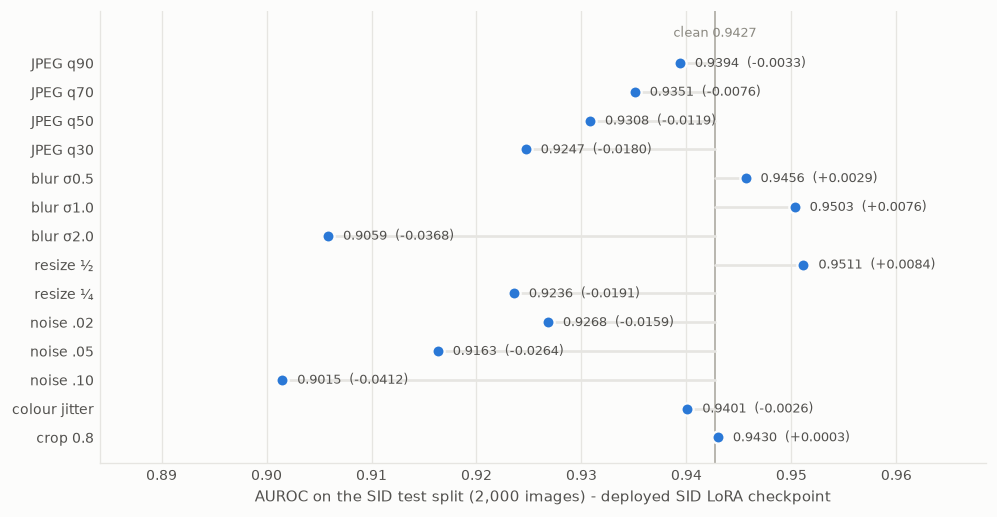

In [9]:
keys = [k for k in ORDER if k != "clean"]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ys = np.arange(len(keys))[::-1]

ax.axvline(CLEAN_T["auroc"], color=NEUTRAL, linewidth=1.2, zorder=1)
ax.annotate(f"clean {CLEAN_T['auroc']:.4f}", (CLEAN_T["auroc"], ys[0] + 0.8),
            fontsize=8, color=INK_MUTE, ha="center", va="bottom")

for y, k in zip(ys, keys):
    v = sid_after["transforms"][k]["auroc"]
    # Hairline connector back to the clean reference makes the gap legible at a glance.
    ax.plot([CLEAN_T["auroc"], v], [y, y], color=GRID, linewidth=1.6,
            solid_capstyle="round", zorder=2)
    ax.scatter([v], [y], s=54, color=BLUE, edgecolor=SURFACE, linewidth=1.4, zorder=3)
    delta = v - CLEAN_T["auroc"]
    ax.annotate(f"{v:.4f}  ({delta:+.4f})", (v, y), textcoords="offset points",
                xytext=(9, 0), va="center", fontsize=8, color=INK_2)

vals_all = [sid_after["transforms"][k]["auroc"] for k in ORDER]
pad = max((max(vals_all) - min(vals_all)) * 0.35, 0.01)
ax.set_yticks(ys, [LABEL[k] for k in keys])
ax.set_xlim(min(vals_all) - pad, max(vals_all) + pad)
ax.set_ylim(-0.9, len(keys) - 0.1 + 0.9)
ax.set_xlabel("AUROC on the SID test split (2,000 images) - deployed SID LoRA checkpoint")
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

Ranking quality is close to flat across the board: mean AUROC over the 14 transforms is 0.9310
against a clean 0.9427 - a 1.2-point average loss - and no single condition drops below 0.90. The
worst case is `noise_0.10` at 0.9015, a 4.1-point drop. Four mild conditions - `blur_0.5`, `blur_1.0`,
`resize_0.5` and `crop_0.8` - actually score a touch *above* clean, best of all `resize_0.5` at +0.0084.

That said, AUROC only measures whether the model still *ranks* AI images above real ones. It says
nothing about whether the fixed decision threshold used for `balanced_accuracy`, `recall` and `fpr` in
the table above is still well placed - which is a separate question the deliverable PDF linked above
works through in more detail.

## 5. What test-time augmentation buys

The deployed inference policy averages predictions over 5 transforms with a trimmed mean. The question
is whether that is worth roughly 5x the inference cost.

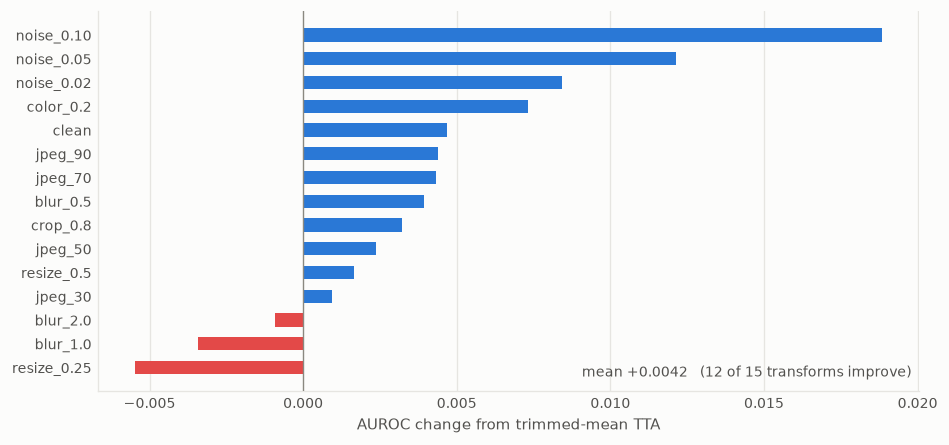

,single,tta,delta
transform,,,
resize_0.25,0.9236,0.9181,-0.0055
blur_1.0,0.9503,0.9469,-0.0034
blur_2.0,0.9059,0.9049,-0.0009
jpeg_30,0.9247,0.9256,0.0009
resize_0.5,0.9511,0.9528,0.0017
jpeg_50,0.9308,0.9332,0.0024
crop_0.8,0.9430,0.9462,0.0032
blur_0.5,0.9456,0.9496,0.0039
jpeg_70,0.9351,0.9394,0.0043


In [10]:
if sid_tta is None:
    print("TTA robustness artifact not found - skipping this figure")
else:
    shared = [t for t in sid_after["transforms"] if t in sid_tta["transforms"]]
    deltas = pd.DataFrame([
        {
            "transform": t,
            "single": sid_after["transforms"][t]["auroc"],
            "tta": sid_tta["transforms"][t]["auroc"],
            "delta": sid_tta["transforms"][t]["auroc"] - sid_after["transforms"][t]["auroc"],
        }
        for t in shared
    ]).sort_values("delta")

    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    # Diverging encoding about a true zero: one cool pole for gains, one warm for losses.
    colours = [BLUE if d >= 0 else RED for d in deltas["delta"]]
    y = np.arange(len(deltas))
    ax.barh(y, deltas["delta"], height=0.55, color=colours, zorder=3)
    ax.axvline(0, color=INK_MUTE, linewidth=0.8, zorder=4)
    ax.set_yticks(y, deltas["transform"])
    ax.set_xlabel("AUROC change from trimmed-mean TTA")
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

    mean_delta = deltas["delta"].mean()
    n_up = int((deltas["delta"] > 0).sum())
    ax.text(0.99, 0.03, f"mean {mean_delta:+.4f}   ({n_up} of {len(deltas)} transforms improve)",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color=INK_2)

    fig.tight_layout()
    plt.show()
    display(deltas.set_index("transform").round(4))

A mean gain of about +0.004 AUROC, and it is not free everywhere: the three noise settings
gain the most (up to +0.019), while downscaling and blur lose a little. That pattern is consistent with
TTA averaging away high-frequency noise but compounding information that resampling has already
destroyed.

Worth keeping when latency is not binding, and the first thing to drop when it is.